# Import

In [1]:
import os
import re
import glob
import torch
import numpy as np
from PIL import Image
import random
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from typing import List, Dict, Tuple, Optional
from sklearn.model_selection import GroupShuffleSplit
import matplotlib.pyplot as plt 
import seaborn as sns
from tqdm import tqdm
import torch.nn as nn
import torch.optim as optim
import copy
import torchvision.models as models
import torch.nn.functional as F
import torchvision.transforms.functional as TF
from transformers import get_cosine_schedule_with_warmup
from collections import defaultdict
from torch.optim import AdamW
from datetime import datetime
from pathlib import Path
from scipy.stats import pearsonr, spearmanr
import gc
from efficientnet_pytorch import EfficientNet
from torch.utils.data import WeightedRandomSampler
import torch.multiprocessing as mp


/usr/users/deeplearningvse/deeplearningvse_18/ATP_projet/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
WELL_DIR_PATTERN_TRAIN = re.compile(
    r"^(?P<well_id>[0-9a-fA-F]+)_(?P<atp>\d+)_(?P<conc>[A-Za-z]+)_(?P<date>\d+)$"
)

WELL_DIR_PATTERN_TEST = re.compile(
    r"^(?P<well_id>[0-9a-fA-F]+)_(?P<conc>[A-Za-z]+)_(?P<date>\d+)$"
)

train_dir = "data/train" 
test_dir = "data/test"

print(f"Version de PyTorch utilisée : {torch.__version__}")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device : {device}")

print(f"Version PyTorch : {torch.__version__}")
print(f"Version CUDA compilée : {torch.version.cuda}")

Version de PyTorch utilisée : 2.10.0+cu128
Device : cuda
Version PyTorch : 2.10.0+cu128
Version CUDA compilée : 12.8


In [ ]:
gc.collect()

torch.cuda.empty_cache()

print("Mémoire CUDA libérée !")

print(torch.cuda.memory_summary(device=None, abbreviated=False))

def lister_tensors_gpu():
    total_mem = 0
    print(f"{'Type':<25} | {'Taille (Shape)':<20} | {'Mémoire (MB)':<10}")
    print("-" * 60)
    
    for obj in gc.get_objects():
        try:
            if torch.is_tensor(obj) or (hasattr(obj, 'data') and torch.is_tensor(obj.data)):
                if obj.is_cuda:
                    mem_mb = obj.element_size() * obj.nelement() / (1024 ** 2)
                    total_mem += mem_mb
                    print(f"{str(type(obj)):<25} | {str(list(obj.size())):<20} | {mem_mb:.2f} MB")
        except Exception:
            pass
            
    print("-" * 60)
    print(f"Total estimé par ces tenseurs : {total_mem:.2f} MB")

lister_tensors_gpu()

Mémoire CUDA libérée !
|===========================================================================|
|                  PyTorch CUDA memory summary, device ID 0                 |
|---------------------------------------------------------------------------|
|            CUDA OOMs: 0            |        cudaMalloc retries: 0         |
|===========================================================================|
|        Metric         | Cur Usage  | Peak Usage | Tot Alloc  | Tot Freed  |
|---------------------------------------------------------------------------|
| Allocated memory      |      0 B   |      0 B   |      0 B   |      0 B   |
|       from large pool |      0 B   |      0 B   |      0 B   |      0 B   |
|       from small pool |      0 B   |      0 B   |      0 B   |      0 B   |
|---------------------------------------------------------------------------|
| Active memory         |      0 B   |      0 B   |      0 B   |      0 B   |
|       from large pool |      0 B   |   

/usr/users/deeplearningvse/deeplearningvse_18/ATP_projet/.venv/lib/python3.10/site-packages/torch/__init__.py:1146: FutureWarning: `torch.distributed.reduce_op` is deprecated, please use `torch.distributed.ReduceOp` instead
  return isinstance(obj, torch.Tensor)
/tmp/deeplearningvse_18-155353/ipykernel_450777/2922302643.py:18: FutureWarning: `torch.distributed.reduce_op` is deprecated, please use `torch.distributed.ReduceOp` instead
  if torch.is_tensor(obj) or (hasattr(obj, 'data') and torch.is_tensor(obj.data)):


------------------------------------------------------------
Total estimé par ces tenseurs : 0.00 MB


# Dataset, Dataloader et Pre-Processing

## Dataset

In [ ]:
def parse_organoid_dataset(root_dir: str, pattern: re.Pattern, is_test: bool = False) -> List[Dict]:
    """
    Traverses the structure and returns a list of metadata for each VIDEO (cavity).
    """
    samples = []
    
    for patient_id in os.listdir(root_dir):
        patient_path = os.path.join(root_dir, patient_id)
        if not os.path.isdir(patient_path): continue

        for well_dir_name in os.listdir(patient_path):
            well_path = os.path.join(patient_path, well_dir_name)
            if not os.path.isdir(well_path): continue

            match = pattern.match(well_dir_name)
            if match:
                metadata = match.groupdict()
                
                atp_value = float(metadata.get("atp", -1.0))

                tif_files = glob.glob(os.path.join(well_path, "*.tif"))
                
                for tif_path in tif_files:
                    samples.append({
                        "path": tif_path,
                        "atp_label": atp_value, 
                        "well_id": metadata["well_id"],
                        "concentration": metadata["conc"],
                        "patient_id": patient_id
                    })
    
    return samples

In [ ]:
def load_tiff_sequence(path: str, img_size: int = 224) -> torch.Tensor:
    """
    Loads a multipage TIFF file and converts it into a tensor (Time, Channels, Height, Width).
    """
    img = Image.open(path)
    frames = []
    
    for i in range(img.n_frames):
        img.seek(i)

        # normalization
        frame = TF.to_tensor(img) 
        
        frames.append(frame)
    
    video_tensor = torch.stack(frames)
    
    
    return video_tensor

To find out how much to crop

In [ ]:
def visualize_crop_experiment(tiff_paths, crop_percent=0.6, img_size=224, num_videos=5):
    """
    Randomly selects ‘num_videos’, applies a proportional CenterCrop,
    then resizes them to img_size, and displays a 5x8 grid.
    """
    selected_paths = random.sample(tiff_paths, min(num_videos, len(tiff_paths)))
    
    fig, axes = plt.subplots(num_videos, 8, figsize=(20, 2.5 * num_videos))
    fig.suptitle(f"Test de Recadrage : CenterCrop à {int(crop_percent*100)}% -> Resize {img_size}x{img_size}", fontsize=16, fontweight='bold')
    
    for row_idx, path in enumerate(selected_paths):
        img = Image.open(path)
        
        orig_w, orig_h = img.size
        crop_h = int(orig_h * crop_percent)
        crop_w = int(orig_w * crop_percent)
        
        n_frames = min(8, img.n_frames)
        
        for col_idx in range(n_frames):
            img.seek(col_idx)
            frame = TF.to_tensor(img) 
            
            frame_cropped = TF.center_crop(frame, output_size=[crop_h, crop_w])
            frame_resized = TF.resize(frame_cropped, [img_size, img_size], antialias=True)
            
            ax = axes[row_idx, col_idx]
            display_img = frame_resized.permute(1, 2, 0).numpy()
            
            if display_img.shape[-1] == 1:
                ax.imshow(display_img.squeeze(), cmap='viridis')
            else:
                ax.imshow(display_img)
                
            ax.axis('off')
            if row_idx == 0:
                ax.set_title(f"Frame {col_idx}")
                
        for col_idx in range(n_frames, 8):
            axes[row_idx, col_idx].axis('off')
                
    plt.tight_layout()
    plt.subplots_adjust(top=0.92)
    plt.show()


Preprocessing takes place here (normalization, standardization, and resizing of the data; batch sampling of the cavities; data augmentation if necessary; and logging of labels)

If there is sufficient GPU memory, test the 256x256 size for the images

In [ ]:
class WellMILDataset(Dataset):
    """
    MIL-oriented dataset: 1 item = 1 entire well (sampled from K wells)
    """
    def __init__(self, wells_dict, num_cavities=40,samples_per_well=1, is_train=True):
        """
        wells_dict: A dictionary where the key is the ‘well_id’ and the value
                     contains the list of paths (.tif) and the ATP.
                     Example: {“well_1”: {‘paths’: [“c1.tif”, “c2.tif”...], “atp”: 10000}}
        """
        self.wells_dict = wells_dict
        self.well_ids = list(wells_dict.keys())
        # self.num_cavities = num_cavities
        self._num_cavities = mp.Value('i', num_cavities)
        self.is_train = is_train
        self.samples_per_well = samples_per_well
        # self.current_epoch = 0
        self._current_epoch = mp.Value('i', 0)
        self.norm_p1 = 0.3319
        self.norm_p99 = 0.7609
        self.norm_mean = 0.4822
        self.norm_std = 0.1152

    @property
    def num_cavities(self):
        return self._num_cavities.value

    @num_cavities.setter
    def num_cavities(self, value):
        self._num_cavities.value = value


    @property
    def current_epoch(self):
        return self._current_epoch.value

    @current_epoch.setter  
    def current_epoch(self, value):
        self._current_epoch.value = value

    def set_epoch(self, epoch: int):
        self._current_epoch.value = epoch

        

    def __len__(self):
        return len(self.well_ids)




    def _augment_cavity(self, video_tensor, rng, strong=False):
        """
        Applies random increases to a tensor [8, 1, 224, 224].
        The transformations are applied to all frames at the same time.
        """
        if rng.random() > 0.5:
            video_tensor = torch.flip(video_tensor, dims=[-1])
            
        if rng.random() > 0.5:
            video_tensor = torch.flip(video_tensor, dims=[-2])

        k_rot = random.randint(0, 3)
        if k_rot > 0:
            video_tensor = torch.rot90(video_tensor, k=k_rot, dims=[-2, -1])

        if random.random() > 0.5:
            alpha = random.uniform(0.9, 1.1)
            beta = random.uniform(-0.1, 0.1)
            
            video_tensor = video_tensor * alpha + beta
            video_tensor = torch.clamp(video_tensor, 0.0, 1.0)

        if rng.random() > 0.8:
            noise = torch.randn_like(video_tensor) * 0.01
            video_tensor = video_tensor + noise
            
            video_tensor = torch.clamp(video_tensor, 0.0, 1.0)

        if strong:
            if rng.random() > 0.5:
                noise = torch.randn_like(video_tensor) * 0.02
                video_tensor = torch.clamp(video_tensor + noise, 0.0, 1.0)

            return video_tensor

    
    def _uniform_sample_paths(self, paths, k, rng):
        """
        MIL-stable sampling:
        - no biased random duplication
        - uniform coverage of the cavities
        """
        n = len(paths)

        if n >= k:
            return rng.sample(paths, k)

        shuffled = paths.copy()
        rng.shuffle(shuffled)

        repeats = (k + n - 1) // n  

        expanded = shuffled * repeats

        rng.shuffle(expanded)

        return expanded[:k]


    def __getitem__(self, idx):
        well_id = self.well_ids[idx]
        well_data = self.wells_dict[well_id]
        all_paths = well_data["paths"]

        atp_log = np.log1p(well_data["atp"])
        is_low_atp = atp_log < 12.7
        
        if self.is_train:
            seed = hash((well_id, self.current_epoch)) % (2**32)
            rng = random.Random(seed)

            selected_paths = self._uniform_sample_paths(
                all_paths,
                self.num_cavities,
                rng
            )
                
        else:
            selected_paths = all_paths

        loaded_videos = []
        for path in selected_paths:
            try:
                video_tensor = load_tiff_sequence(path) 

                crop_percent = 0.65
                orig_h, orig_w = video_tensor.shape[-2], video_tensor.shape[-1]
                crop_h = int(orig_h * crop_percent)
                crop_w = int(orig_w * crop_percent)
                video_tensor = TF.center_crop(video_tensor, output_size=[crop_h, crop_w])

                # RESIZE
                video_tensor = F.interpolate(video_tensor, size=(224, 224), mode="bilinear", align_corners=False)


                if self.is_train:
                    video_tensor = self._augment_cavity(video_tensor, rng, strong=is_low_atp)
                # video_tensor = (video_tensor - 0.5) / 0.5
                video_tensor = video_tensor.clip(self.norm_p1, self.norm_p99)
                video_tensor = (video_tensor - self.norm_mean) / (self.norm_std + 1e-6)
            except Exception as e:
                print(f"Image corrompue ignorée : {path}")
                video_tensor = torch.zeros((8, 1, 224, 224), dtype=torch.float32)

            loaded_videos.append(video_tensor)
                    
        H_tensor = torch.stack(loaded_videos)
        
        raw_atp = well_data["atp"]
        if raw_atp >= 0:
            label = torch.log1p(torch.tensor(raw_atp, dtype=torch.float32))
        else:
            label = torch.tensor(-1.0, dtype=torch.float32)

        return H_tensor, label, well_id

## Useful Functions for the DataLoader

In [ ]:
def calculate_stats(samples):
    """Calculates the mean and standard deviation of ATP labels for a list of samples."""
    labels = np.array([s["atp_label"] for s in samples])
    return {
        "mean": np.mean(labels),
        "std": np.std(labels),
        "min": np.min(labels),
        "max": np.max(labels),
        "count": len(labels)
    }

def find_balanced_split(all_samples, patient_ids, test_size=0.2, tolerance=0.10, max_attempts=200):
    """
    Finds a seed that produces similar Train/Val distributions.

    Args:
        tolerance (float): Maximum acceptable relative deviation (e.g., 0.10 = 10%).
        max_attempts (int): Number of attempts before giving up.
    """
    print(f"Seeking a Balanced Distribution (Tolérance: {tolerance*100}%)...")
    
    best_split = None
    best_diff = float('inf')

    for seed in range(max_attempts):
        splitter = GroupShuffleSplit(n_splits=1, test_size=test_size, random_state=seed)
        try:
            train_idx, val_idx = next(splitter.split(all_samples, groups=patient_ids))
        except StopIteration:
            continue 
            
        train_sub = [all_samples[i] for i in train_idx]
        val_sub = [all_samples[i] for i in val_idx]
        
        stats_train = calculate_stats(train_sub)
        stats_val = calculate_stats(val_sub)

        diff_mean = abs(stats_train["mean"] - stats_val["mean"]) / stats_train["mean"]
        diff_std = abs(stats_train["std"] - stats_val["std"]) / stats_train["std"]
        
        total_diff = diff_mean + diff_std
        
        if diff_mean < tolerance and diff_std < tolerance:
            print(f"✅ Split trouvé à l'essai n°{seed} !")
            print(f"   Différence Moyenne : {diff_mean:.2%}")
            print(f"   Différence Std     : {diff_std:.2%}")
            return train_sub, val_sub
        
        if total_diff < best_diff:
            best_diff = total_diff
            best_split = (train_sub, val_sub)

    print(f"Aucun split parfait trouvé après {max_attempts} essais.")
    print(f"Utilisation du meilleur trouvé (Diff cumulée: {best_diff:.2%})")
    return best_split


def group_samples_by_well(samples):
    """
    Convert a flat list of cavities into a dictionary grouped by well.
    Format expected by WellMILDataset.
    """
    wells_dict = {}
    for s in samples:
        wid = s["well_id"]
        if wid not in wells_dict:
            wells_dict[wid] = {
                "paths": [],
                "atp": s["atp_label"]
            }
        wells_dict[wid]["paths"].append(s["path"])
    return wells_dict


def make_weighted_sampler(wells_dict, threshold=12.7):
    weights = []
    for well_id, data in wells_dict.items():
        atp_log = np.log1p(data["atp"])
        n_cavities = len(data["paths"])
        
        if atp_log < threshold:
            w = 1.2 if n_cavities < 50 else 1.2
        else:
            w = 1.0
            
        weights.append(w)
    
    weights = np.array(weights) / np.sum(weights)
    return WeightedRandomSampler(
        weights=torch.from_numpy(weights).float(),
        num_samples=len(weights),
        replacement=True
    )

## Dataloader

In [ ]:
def create_auto_dataloaders(
    data_dir: str, 
    batch_size: int = 2,
    val_split: float = 0.2,
    num_cavities: int = 40, 
    tolerance: float = 0.15,
    patient_split_dict: dict = None
):
    all_samples = parse_organoid_dataset(data_dir, WELL_DIR_PATTERN_TRAIN)


    if patient_split_dict is not None:
        print("Using the provided manual split (patient_split_dict)...")
        train_samples = [s for s in all_samples if s["patient_id"] in patient_split_dict["train"]]
        val_samples = [s for s in all_samples if s["patient_id"] in patient_split_dict["val"]]
        
        if not train_samples or not val_samples:
            raise ValueError("Error: The manual split generated an empty list. Check the patient IDs.")
            
    else:
        print("Automatic calculation of a new balanced split...")
        patient_ids = [s["patient_id"] for s in all_samples]
        
        train_samples, val_samples = find_balanced_split(
            all_samples, 
            patient_ids, 
            test_size=val_split, 
            tolerance=tolerance
        )
        
        train_pids = sorted(list(set(s["patient_id"] for s in train_samples)))
        val_pids = sorted(list(set(s["patient_id"] for s in val_samples)))
        
        print("\n" + "="*60)
        print("REPRODUCIBLE SPLIT ACHIEVED")
        print("="*60)
        print("mon_split_sauvegarde = {")
        print(f"    'train': {train_pids},")
        print(f"    'val': {val_pids}")
        print("}")
        print("="*60 + "\n")

    s_t = calculate_stats(train_samples)
    s_v = calculate_stats(val_samples)
    
    print("\n" + "="*50)
    print(f"STATISTIQUES FINALES DES CAVITÉS")
    print("="*50)
    print(f"{'Metrique':<10} | {'Train':<15} | {'Validation':<15}")
    print("-" * 50)
    print(f"{'Moyenne':<10} | {s_t['mean']:<15.2f} | {s_v['mean']:<15.2f}")
    print(f"{'Std':<10} | {s_t['std']:<15.2f} | {s_v['std']:<15.2f}")
    print(f"{'Min':<10} | {s_t['min']:<15.2f} | {s_v['min']:<15.2f}")
    print(f"{'Max':<10} | {s_t['max']:<15.2f} | {s_v['max']:<15.2f}")
    print("="*50 + "\n")

    train_wells_dict = group_samples_by_well(train_samples)
    val_wells_dict = group_samples_by_well(val_samples)
    
    print(f"PUITS OBTENUS :")
    print(f"  -> Train : {len(train_wells_dict)} puits")
    print(f"  -> Val   : {len(val_wells_dict)} puits\n")



    train_dataset = WellMILDataset(
        wells_dict=train_wells_dict, 
        num_cavities=num_cavities, 
        samples_per_well=1,
        is_train=True
    )
    
    val_dataset = WellMILDataset(
        wells_dict=val_wells_dict, 
        num_cavities=num_cavities, 
        samples_per_well=1,
        is_train=False
    )
    

    WORKERS = 5

    sampler = make_weighted_sampler(train_wells_dict, threshold=12.7)

    sampler = make_weighted_sampler(train_wells_dict)
    well_ids = list(train_wells_dict.keys())

    sampled_atps = []
    for idx in sampler:
        well_id = well_ids[idx]
        atp_log = np.log1p(train_wells_dict[well_id]["atp"])
        sampled_atps.append(atp_log)

    sampled_atps = np.array(sampled_atps)
    print(f"Mean ATP samplé  : {sampled_atps.mean():.3f}")
    print(f"Std ATP samplé      : {sampled_atps.std():.3f}")
    print(f"% faible ATP (<12.7): {(sampled_atps < 12.7).mean()*100:.1f}%")

    all_atps = np.array([np.log1p(d["atp"]) for d in train_wells_dict.values()])
    print(f"\nMoyenne ATP original : {all_atps.mean():.3f}")
    print(f"% faible ATP original: {(all_atps < 12.7).mean()*100:.1f}%")


    train_loader = DataLoader(
        train_dataset, 
        batch_size=batch_size, 
        # sampler=sampler,      
        shuffle=True,       
        num_workers=WORKERS, 
        pin_memory=True,
        persistent_workers=True
    )
    
    val_loader = DataLoader(
        val_dataset, 
        batch_size=1, 
        shuffle=False, 
        num_workers=WORKERS,
        pin_memory=True,
        persistent_workers=True
    )

    
    return train_loader, val_loader

In [10]:
mon_split_sauvegarde = {
    'train': ['CGR0010', 'CGR0030', 'CGR0065', 'CGR0068', 'CGR0070', 'CGR0072', 'CGR0073', 'CGR0093', 'CGR0094', 'CGR0106', 'CGR0110', 'CGR0119', 'CGR0121', 'PGR0011', 'PGR0020', 'PGR0021', 'PGR0044', 'PGR0046', 'PGR0047', 'PGR0052', 'PGR0057', 'PGR0066', 'PGR0095', 'PGR0110', 'PGR0122', 'PGR0127', 'PGR0135', 'PGR0138'],
    'val': ['CGR0079', 'CGR0099', 'CGR0103', 'CGR0104', 'CGR0112', 'PGR0004', 'PGR0093', 'PGR0129']
}

train_loader, val_loader = create_auto_dataloaders("data/train", batch_size=2, num_cavities=40,tolerance=0.03,patient_split_dict=mon_split_sauvegarde)  
print(f"len(train_loader) = {len(train_loader)}")
# data, label, well = next(iter(train_loader))
# print(f"shape d'un élément du dataloader : {data.shape}")

🔄 Utilisation du split manuel fourni (patient_split_dict)...

📊 STATISTIQUES FINALES DES CAVITÉS
Metrique   | Train           | Validation     
--------------------------------------------------
Moyenne    | 878636.24       | 855464.21      
Std        | 609218.03       | 609472.75      
Min        | 14719.00        | 22696.00       
Max        | 2499934.00      | 1913744.00     

🧪 PUITS OBTENUS :
  -> Train : 575 puits
  -> Val   : 156 puits

Moyenne ATP samplé  : 13.131
Std ATP samplé      : 1.033
% faible ATP (<12.7): 33.7%

Moyenne ATP original : 13.273
% faible ATP original: 26.1%
len(train_loader) = 288


In [ ]:
def get_mean_value_atp(train_loader):
    sum_value_label = 0.0
    number_well = 0

    with torch.no_grad():
        for (datas, labels, wells) in tqdm(train_loader):
            sum_value_label += labels.sum().item()
            number_well += labels.size(0)

    mean_target_value = sum_value_label / number_well
    print(f"La moyenne exacte de l'ATP (Log1p) est : {mean_target_value}")  # 13.27303


## To view the image size, the number of wells, the correlation between well size and ATP, and statistics on the labels:

In [ ]:
def analyze_image_shapes(data_dir, pattern):
    """
    Iterates through the dataset to collect the original dimensions (W, H).
    Displays a comprehensive analysis of the images' geometry.
    """
    print("Parsing du dataset...")
    samples = parse_organoid_dataset(data_dir, pattern)
    
    widths = []
    heights = []
    aspect_ratios = []
    
    print(f"Analyse des dimensions de {len(samples)} vidéos...")
    
    for sample in tqdm(samples):
        try:
            with Image.open(sample["path"]) as img:
                w, h = img.size
                widths.append(w)
                heights.append(h)
                aspect_ratios.append(w / h)
        except Exception as e:
            print(f"Erreur sur {sample['path']}: {e}")

    plt.figure(figsize=(15, 6))
    
    plt.subplot(1, 2, 1)
    sns.scatterplot(x=widths, y=heights, alpha=0.3)
    plt.plot([0, max(widths)], [0, max(widths)], 'r--', label="Carré parfait (y=x)")
    plt.title("Distribution des Tailles (Largeur vs Hauteur)")
    plt.xlabel("Largeur (px)")
    plt.ylabel("Hauteur (px)")
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    plt.subplot(1, 2, 2)
    sns.histplot(aspect_ratios, bins=50, kde=True, color='green')
    plt.axvline(x=1.0, color='r', linestyle='--', label="Carré (Ratio=1.0)")
    plt.title("Histogramme des Ratios d'Aspect (Largeur / Hauteur)")
    plt.xlabel("Ratio (1.0 = Carré, >1 = Large, <1 = Haut)")
    plt.legend()
    
    plt.tight_layout()
    plt.show()
    
    print("\n" + "="*40)
    print(f"STATISTIQUES DES DIMENSIONS")
    print("="*40)
    print(f"Nombre d'images : {len(widths)}")
    print(f"Largeur  : Min={min(widths)}, Max={max(widths)}, Moy={np.mean(widths):.1f}")
    print(f"Hauteur  : Min={min(heights)}, Max={max(heights)}, Moy={np.mean(heights):.1f}")
    print(f"Ratio    : Moy={np.mean(aspect_ratios):.2f} (std={np.std(aspect_ratios):.2f})")
    
    ratio_mean = np.mean(aspect_ratios)
    if 0.9 < ratio_mean < 1.1:
        print("\nCONCLUSION : Les images sont globalement carrées.")
        print("   -> Resize direct (224, 224) recommandé sans crainte.")
    else:
        print("\nCONCLUSION : Les images sont rectangulaires.")
        print("   -> Attention à la déformation (Squish).")
        print("   -> Envisagez le Padding (Letterbox) si la forme exacte compte.")
    print("="*40)


In [ ]:
def analyze_cavities_per_well(data_dir, pattern):
    """
    Iterates through the dataset to count the number of cavities in each well.
    Displays the distribution to help determine the value of the ‘num_cavities’ parameter.
    """
    print(" Parsing du dataset...")
    samples = parse_organoid_dataset(data_dir, pattern)
    
    cavities_per_well = defaultdict(int)
    for sample in samples:
        cavities_per_well[sample["well_id"]] += 1
        
    counts = list(cavities_per_well.values())
    
    if not counts:
        print(" Aucun puits trouvé.")
        return

    min_c = np.min(counts)
    max_c = np.max(counts)
    mean_c = np.mean(counts)
    median_c = np.median(counts)
    p25 = np.percentile(counts, 25) 
    p75 = np.percentile(counts, 75) 
    
    plt.figure(figsize=(15, 6))
    
    plt.subplot(1, 2, 1)
    sns.histplot(counts, bins=20, kde=True, color='purple')
    plt.axvline(x=mean_c, color='red', linestyle='--', label=f"Moyenne ({mean_c:.1f})")
    plt.axvline(x=median_c, color='orange', linestyle='-', label=f"Médiane ({median_c:.0f})")
    plt.title("Distribution du nombre de cavités par puits")
    plt.xlabel("Nombre de cavités")
    plt.ylabel("Nombre de puits")
    plt.legend()
    
    plt.subplot(1, 2, 2)
    sns.boxplot(y=counts, color='purple', width=0.3)
    plt.title("Dispersion et Outliers")
    plt.ylabel("Nombre de cavités")
    plt.grid(True, alpha=0.3, axis='y')
    
    plt.tight_layout()
    plt.show()
    
    print("\n" + "="*50)
    print(f"STATISTIQUES DES CAVITÉS PAR PUITS")
    print("="*50)
    print(f"Nombre total de puits   : {len(counts)}")
    print(f"Nombre total de cavités : {sum(counts)}")
    print("-" * 50)
    print(f"Minimum  : {min_c}")
    print(f"Maximum  : {max_c}")
    print(f"Moyenne  : {mean_c:.1f}")
    print(f"Médiane  : {median_c:.0f}")
    print(f"Q1 (25%) : {p25:.0f} (25% des puits ont <= {p25:.0f} cavités)")
    print(f"Q3 (75%) : {p75:.0f} (75% des puits ont <= {p75:.0f} cavités)")
    
    print("-" * 50)
    print("RECOMMANDATION POUR 'num_cavities' (Bag Subsampling) :")
    
    suggested_num = int(median_c * 0.8)
    
    print(f"-> Un bon point de départ pour l'entraînement serait entre {int(p25)} et {int(median_c)}.")
    print(f"-> Si ta VRAM te le permet (11Go), tu peux tester num_cavities = {suggested_num}.")
    if min_c < suggested_num:
        print(f"Note : Les puits ayant moins de {suggested_num} cavités verront certaines vidéos dupliquées (suréchantillonnage) lors du tirage.")
    else:
        print("Aucun puits ne nécessitera de duplication (tirage sans remise garanti).")
    print("="*50 + "\n")


In [ ]:
def analyze_cavity_atp_correlation(data_dir, pattern):
    """
    Vérifie si la taille d'un puits (nombre de cavités) 
    est corrélée à sa valeur d'ATP.
    """
    print("Parsing du dataset pour analyse de corrélation...")
    samples = parse_organoid_dataset(data_dir, pattern)

    wells_info = defaultdict(lambda: {"count": 0, "atp": 0.0})

    for s in samples:
        wid = s["well_id"]
        wells_info[wid]["count"] += 1
        wells_info[wid]["atp"] = s["atp_label"]

    counts = []
    atps = []
    log_atps = []

    for wid, info in wells_info.items():
        if info["atp"] >= 0:
            counts.append(info["count"])
            atps.append(info["atp"])
            log_atps.append(np.log1p(info["atp"])) 

    if not counts:
        print("Aucun puits valide trouvé avec un ATP >= 0.")
        return

    corr_spearman, p_val_spearman = spearmanr(counts, atps)
    corr_pearson, p_val_pearson = pearsonr(counts, log_atps)

    plt.figure(figsize=(10, 6))

    sns.regplot(
        x=counts, 
        y=log_atps, 
        scatter_kws={'alpha':0.6, 'color': 'teal'}, 
        line_kws={'color':'red', 'label': 'Tendance (Régression)'}
    )
    
    plt.title(f"Biais de taille : Nombre de cavités vs Target Log(1+ATP)")
    plt.xlabel("Nombre de cavités dans le puits")
    plt.ylabel("Label d'entraînement : Log(1 + ATP)")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

    print("\n" + "="*60)
    print(f"ANALYSE DE CORRÉLATION (TAILLE DU PUITS vs ATP)")
    print("="*60)
    print(f"Nombre de puits analysés : {len(counts)}")
    print("-" * 60)
    print(f"Corrélation de Spearman (Ordinale) : {corr_spearman:.3f} (p-value: {p_val_spearman:.2e})")
    print(f"Corrélation de Pearson (Linéaire)  : {corr_pearson:.3f} (p-value: {p_val_pearson:.2e})")
    print("-" * 60)

    if abs(corr_spearman) > 0.25 or abs(corr_pearson) > 0.25:
        print("DANGER IDENTIFIÉ : Il y a une corrélation significative !")
        print(" -> Les puits contenant beaucoup de cavités ont des valeurs d'ATP différentes de la moyenne.")
        print(" -> Si tu suréchantillonnes les gros puits (samples_per_well > 1),")
        print("    ton modèle va biaiser son apprentissage vers ces valeurs d'ATP.")
        print("\nRECOMMANDATION : Utilise STRICTEMENT 'samples_per_well = 1'")
        print("    pour garantir que la Loss MSE soit juste et non biaisée.")
    else:
        print("BONNE NOUVELLE : Pas de corrélation forte détectée.")
        print(" -> Le nombre de cavités est indépendant de la valeur de l'ATP.")
        print(" -> Ton idée de 'samples_per_well' dynamique est mathématiquement jouable,")
        print("    mais par mesure de sécurité et de simplicité, garder 'samples_per_well = 1'")
        print("    et augmenter le nombre d'époques (epochs) reste la méthode la plus pure.")
    print("="*60 + "\n")

# analyze_cavity_atp_correlation("data/train", WELL_DIR_PATTERN_TRAIN)

In [ ]:
def analyze_atp_distribution(train_loader):
    all_labels = []

    with torch.no_grad():
        for (datas, labels, wells) in tqdm(train_loader, desc="Extraction des labels"):
            all_labels.extend(labels.cpu().numpy())
            
    all_labels = np.array(all_labels)
    
    mean_val = np.mean(all_labels)
    std_val = np.std(all_labels)
    min_val = np.min(all_labels)
    q25 = np.percentile(all_labels, 25)
    median_val = np.median(all_labels) 
    q75 = np.percentile(all_labels, 75)
    max_val = np.max(all_labels)
    
    print("\n" + "="*45)
    print("STATISTIQUES DES LABELS ATP (Log1p)")
    print("="*45)
    print(f"Nombre total d'échantillons : {len(all_labels):,}")
    print(f"Moyenne      : {mean_val:.4f}")
    print(f"Écart-type   : {std_val:.4f}")
    print("-" * 45)
    print(f"Minimum      : {min_val:.4f}")
    print(f"Quartile 25% : {q25:.4f}")
    print(f"Médiane (50%): {median_val:.4f}")
    print(f"Quartile 75% : {q75:.4f}")
    print(f"Maximum      : {max_val:.4f}")
    print("="*45 + "\n")

    fig, (ax_box, ax_hist) = plt.subplots(2, 1, sharex=True, 
                                          gridspec_kw={"height_ratios": (.15, .85)}, 
                                          figsize=(10, 6))
    
    sns.boxplot(x=all_labels, ax=ax_box, color="lightblue")
    ax_box.set_title("Distribution des valeurs d'ATP (Log1p)", fontsize=14, fontweight='bold')
    ax_box.set_xlabel("") 
    
    sns.histplot(x=all_labels, ax=ax_hist, bins=50, kde=True, color="royalblue")
    ax_hist.set_xlabel("Valeurs d'ATP (Log1p)", fontsize=12)
    ax_hist.set_ylabel("Fréquence (Nombre d'organoïdes/puits)", fontsize=12)
    
    ax_hist.axvline(mean_val, color='crimson', linestyle='--', linewidth=2, label=f'Moyenne ({mean_val:.2f})')
    ax_hist.axvline(median_val, color='forestgreen', linestyle='-', linewidth=2, label=f'Médiane ({median_val:.2f})')
    
    ax_hist.legend()
    plt.tight_layout()
    plt.show()

    return mean_val, std_val

# mean_atp, std_atp = analyze_atp_distribution(train_loader)

# Architecture

## The Spatial Encoder:

### ResNet

In [ ]:
class SpatialEncoderResNet(nn.Module):
    def __init__(self, backbone_name='resnet18', trainable_layers=None):
        """
        backbone_name: ‘resnet18’ or ‘resnet34’
        trainable_layers: A list of keywords to unfreeze certain layers (e.g., [‘layer4’, ‘layer3’])
                          If None or [], the entire network is frozen.
        """
        super().__init__()

        if trainable_layers is None:
            trainable_layers = []
            
        if backbone_name == 'resnet18':
            self.backbone = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
            self.feature_dim = 512
        elif backbone_name == 'resnet34':
            self.backbone = models.resnet34(weights=models.ResNet34_Weights.DEFAULT)
            self.feature_dim = 512
        else:
            raise ValueError("backbone_name doit être 'resnet18' ou 'resnet34'")

        orig_conv = self.backbone.conv1
        self.backbone.conv1 = nn.Conv2d(
            orig_conv.out_channels,
            kernel_size=orig_conv.kernel_size,
            stride=orig_conv.stride,
            padding=orig_conv.padding,
            bias=False
        )
        with torch.no_grad():
            self.backbone.conv1.weight[:] = orig_conv.weight[:, 0:1, :, :]

        self.backbone.fc = nn.Identity()

        for name, param in self.backbone.named_parameters():
            if any(keyword in name for keyword in trainable_layers):
                param.requires_grad = True
            else:
                param.requires_grad = False
                
        self.backbone.eval()

    def train(self, mode=True):
        """
        Even if the main loop calls `model.train()`,
        we force our extractor to remain in evaluation mode.
        Batch Normalization will thus remain fixed to the ImageNet statistics.
        """
        super().train(mode)
        self.backbone.eval()

    def forward(self, x):
        B, T, C, H, W = x.size()
        
        x_flat = x.view(B * T, C, H, W)
        
        feat = self.backbone(x_flat) 
            
        out = feat.view(B, T, -1) 
        
        return out

#### Sanity check :

In [ ]:
feature_extractor = SpatialEncoderResNet().to(device)
feature_extractor.eval()

inputs, labels, well_ids = next(iter(train_loader))

print(f"1. Shape Input brute (Sortie Loader) : {inputs.shape}")
B, N, T, C, H, W = inputs.shape

inputs_flat = inputs.view(B * N, T, C, H, W)

print(f"2. Shape Input aplatie    : {inputs_flat.shape}")
inputs_flat = inputs_flat.to(device)
labels = labels.to(device)

with torch.no_grad():
    spatial_features = feature_extractor(inputs_flat)

print(f"3. Shape Output  : {spatial_features.shape}")
well_features = spatial_features.view(B, N, T, -1)
print(f"4. Shape Output restructurée  : {well_features.shape}")

print(f"5. Device Output   : {spatial_features.device}") 

del feature_extractor, labels, well_ids, inputs_flat, well_features

Image corrompue ignorée : data/train/PGR0095/62eee8e97e21b5c1f0ca7cdc078a91e8_1430253_ctrl_120923/62eee8e97e21b5c1f0ca7cdc078a91e8_1430253_35.tif
Image corrompue ignorée : data/train/PGR0046/82943f44f6fe969f37e1c3908fdae9b6_1529395_ctrl_071123/82943f44f6fe969f37e1c3908fdae9b6_1529395_76.tif
Image corrompue ignorée : data/train/PGR0095/62eee8e97e21b5c1f0ca7cdc078a91e8_1430253_ctrl_120923/62eee8e97e21b5c1f0ca7cdc078a91e8_1430253_18.tif
Image corrompue ignorée : data/train/PGR0046/82943f44f6fe969f37e1c3908fdae9b6_1529395_ctrl_071123/82943f44f6fe969f37e1c3908fdae9b6_1529395_10.tif
Image corrompue ignorée : data/train/PGR0046/82943f44f6fe969f37e1c3908fdae9b6_1529395_ctrl_071123/82943f44f6fe969f37e1c3908fdae9b6_1529395_31.tifImage corrompue ignorée : data/train/PGR0095/62eee8e97e21b5c1f0ca7cdc078a91e8_1430253_ctrl_120923/62eee8e97e21b5c1f0ca7cdc078a91e8_1430253_9.tif

Image corrompue ignorée : data/train/PGR0095/62eee8e97e21b5c1f0ca7cdc078a91e8_1430253_ctrl_120923/62eee8e97e21b5c1f0ca7cdc078

## Time Encoder

Here, we use a transformer to account for the temporal nature of the data and thereby improve the prediction.

Possible improvement: Replace mean pooling with attention pooling: attention_weights = softmax(Wx) and pooled = sum(attention_weights * x)


In [ ]:
class PositionalEncoding1D(nn.Module):
    """
    Trainable positional encoding with initialization
    """
    def __init__(self, d_model: int, max_len: int = 8):
        super().__init__()
        self.pos_embedding = nn.Parameter(torch.empty(1, max_len, d_model))
        nn.init.normal_(self.pos_embedding, std=0.02)

    def forward(self, x):
        return x + self.pos_embedding[:, :x.size(1), :]


class TemporalTransformer(nn.Module):
    def __init__(
        self, 
        input_dim: int = 512,  
        d_model: int = 256,      
        n_heads: int = 4,      
        num_layers: int = 2,   
        ff_dim: int = 512,       
        dropout: float = 0.4,   
        max_len: int = 8       
    ):
        super().__init__()
        
        self.input_norm = nn.LayerNorm(input_dim)
        
        self.projection = nn.Sequential(
            nn.Linear(input_dim, input_dim),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(input_dim, d_model)            
        )
        
        self.proj_drop = nn.Dropout(dropout)
        
        self.pos_encoder = PositionalEncoding1D(d_model=d_model, max_len=max_len)
        
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=n_heads,
            dim_feedforward=ff_dim,
            dropout=dropout,   
            activation='gelu', 
            batch_first=True,  
            norm_first=True 
        )
        
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        
    def forward(self, x):
        """
        x attendu : [Batch, Time, 1280]
        Retourne  : [Batch, d_model]
        """
        x = self.input_norm(x)
        
        x = self.proj_drop(self.projection(x))
        
        x = self.pos_encoder(x)
        x = self.transformer(x)
        
        x_pooled = x.mean(dim=1)
        
        return x_pooled

Image corrompue ignorée : data/train/CGR0119/b3f587043df02aa884fea58d919b31a6_1271657_ctrl_010725/b3f587043df02aa884fea58d919b31a6_1271657_57.tif
Image corrompue ignorée : data/train/CGR0093/dea9eb488f1cc3b97473392b1d9f4ea5_998474_low_010725/dea9eb488f1cc3b97473392b1d9f4ea5_998474_75.tifImage corrompue ignorée : data/train/PGR0046/4a153dd521db22191103a5666e2437a3_1850725_low_071123/4a153dd521db22191103a5666e2437a3_1850725_80.tifImage corrompue ignorée : data/train/CGR0119/b3f587043df02aa884fea58d919b31a6_1271657_ctrl_010725/b3f587043df02aa884fea58d919b31a6_1271657_13.tif
Image corrompue ignorée : data/train/CGR0073/45359ab17956cb3b641f311b89d0600f_1018056_low_180325/45359ab17956cb3b641f311b89d0600f_1018056_11.tif
Image corrompue ignorée : data/train/CGR0093/dea9eb488f1cc3b97473392b1d9f4ea5_998474_low_010725/dea9eb488f1cc3b97473392b1d9f4ea5_998474_10.tifImage corrompue ignorée : data/train/PGR0046/4a153dd521db22191103a5666e2437a3_1850725_low_071123/4a153dd521db22191103a5666e2437a3_18507

#### Sanity check :

In [ ]:
temporal_model = TemporalTransformer().to(device)
temporal_model.eval()


print(f"1. Shape Input  (depuis ResNet)     : {spatial_features.shape}") 

with torch.no_grad():
    temporal_embeddings_flat = temporal_model(spatial_features)


print(f"2. Shape Output (Transformer plat)  : {temporal_embeddings_flat.shape}")    

B, N, T, C, H, W = inputs.shape

well_embeddings = temporal_embeddings_flat.view(B, N, -1)

print(f"3. Shape Output (Regroupée puits)   : {well_embeddings.shape}")

del temporal_model, spatial_features, temporal_embeddings_flat

1. Shape Input  (depuis ResNet)     : torch.Size([80, 8, 512])
2. Shape Output (Transformer plat)  : torch.Size([80, 128])
3. Shape Output (Regroupée puits)   : torch.Size([2, 40, 128])


/tmp/deeplearningvse_18-155353/ipykernel_2850478/2319472722.py:51: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)


1. Shape Input  (depuis ResNet)     : torch.Size([80, 8, 512])
2. Shape Output (Transformer plat)  : torch.Size([80, 256])
3. Shape Output (Regroupée puits)   : torch.Size([2, 40, 256])


/tmp/deeplearningvse_18-155353/ipykernel_3819121/815964970.py:57: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)


1. Shape Input  (depuis ResNet)     : torch.Size([80, 8, 512])
2. Shape Output (Transformer plat)  : torch.Size([80, 256])
3. Shape Output (Regroupée puits)   : torch.Size([2, 40, 256])


/tmp/deeplearningvse_18-155353/ipykernel_3822523/815964970.py:57: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)


1. Shape Input  (depuis ResNet)     : torch.Size([80, 8, 512])


/tmp/deeplearningvse_18-155353/ipykernel_450777/815964970.py:57: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)


2. Shape Output (Transformer plat)  : torch.Size([80, 256])
3. Shape Output (Regroupée puits)   : torch.Size([2, 40, 256])


## Transformer MIL

In [ ]:
class MILAttentionPooling(nn.Module):
    """
    Gated Attention Pooling Mechanism.
    Calculates the importance of each well and produces the aggregated embedding of the well.
    Formula: a_i = softmax(w^T * tanh(V * h'_i))
              z = sum(a_i * h'_i)
    """
    def __init__(self, in_features: int = 256, hidden_features: int = 128,temperature: float = 0.5):
        super().__init__()

        self.temperature = temperature

        self.attention_V = nn.Linear(in_features, hidden_features, bias=True)
        self.attention_w = nn.Linear(hidden_features, 1, bias=False)

    def forward(self, h_prime):
        attn_scores = self.attention_w(torch.tanh(self.attention_V(h_prime)))
        
        a_weights = F.softmax(attn_scores / self.temperature, dim=1)
        
        z = torch.sum(a_weights * h_prime, dim=1)
        
        return z, a_weights


class WellEmbeddingExtractor(nn.Module):
    """
    Module that takes the temporal embeddings of the N cavities in a well
    and returns the global embedding z of the well.
    """
    def __init__(
        self, 
        d_model: int = 256, 
        n_heads: int = 4, 
        ff_dim: int = 512, 
        dropout: float = 0.1,
        temperature: float = 0.7,
    ):
        super().__init__()
        
        self.layer_norm = nn.LayerNorm(d_model)
        
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=n_heads,
            dim_feedforward=ff_dim,
            dropout=dropout,
            activation='gelu',
            batch_first=True,
            norm_first=True 
        )
        self.inter_cavity_transformer = nn.TransformerEncoder(encoder_layer, num_layers=1)
        
        self.attention_pooling = MILAttentionPooling(in_features=d_model,temperature=temperature)

    def forward(self, H):
        h_norm = self.layer_norm(H)
        
        h_prime = self.inter_cavity_transformer(h_norm)
        z, a_weights = self.attention_pooling(h_prime)
        
        return z, a_weights

#### Sanity check :

In [ ]:
well_extractor = WellEmbeddingExtractor(d_model=256).to(device)


print(f"Input H shape             : {well_embeddings.shape}")          

z_embedding, attention_weights = well_extractor(well_embeddings)

print(f"Output z shape (Puits)    : {z_embedding.shape}")      
print(f"Attention weights shape   : {attention_weights.shape}") 

sum_weights_well_0 = attention_weights[0].sum().item()
print(f"Somme des poids (Puits 0) : {sum_weights_well_0:.4f}") 

del well_extractor, well_embeddings, attention_weights, sum_weights_well_0

/tmp/deeplearningvse_18-155353/ipykernel_3819121/1295756870.py:77: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.inter_cavity_transformer = nn.TransformerEncoder(encoder_layer, num_layers=1)


Input H shape             : torch.Size([2, 40, 256])
Output z shape (Puits)    : torch.Size([2, 256])
Attention weights shape   : torch.Size([2, 40, 1])
Somme des poids (Puits 0) : 1.0000


Input H shape             : torch.Size([2, 40, 256])
Output z shape (Puits)    : torch.Size([2, 256])
Attention weights shape   : torch.Size([2, 40, 1])
Somme des poids (Puits 0) : 1.0000


/tmp/deeplearningvse_18-155353/ipykernel_3822523/1295756870.py:77: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.inter_cavity_transformer = nn.TransformerEncoder(encoder_layer, num_layers=1)


Input H shape             : torch.Size([2, 40, 256])


/tmp/deeplearningvse_18-155353/ipykernel_450777/1295756870.py:77: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.inter_cavity_transformer = nn.TransformerEncoder(encoder_layer, num_layers=1)


Output z shape (Puits)    : torch.Size([2, 256])
Attention weights shape   : torch.Size([2, 40, 1])
Somme des poids (Puits 0) : 1.0000


## Final Regression

In [ ]:
class RegressionMLP(nn.Module):
    """
    Final regressor: takes the embedding of the well (z) and predicts the ATP value.
    Architecture: 256 -> 128 -> 1 with GELU and Dropout.
    """
    def __init__(self, in_features: int = 256, hidden_features: int = 64, dropout: float = 0.4):
        super().__init__()
        self.mlp = nn.Sequential(
            nn.Linear(in_features, hidden_features),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_features, 1)
        )

    def forward(self, z):
        out = self.mlp(z)
        
        return out.squeeze(-1)

#### Sanity check :

In [ ]:
FinalRegMLP = RegressionMLP().to(device)

print(f"Shape Input  : {z_embedding.shape}")

prediction = FinalRegMLP(z_embedding)

print(f"Shape Output : {prediction.shape}") 

del FinalRegMLP, z_embedding, prediction

Shape Input  : torch.Size([2, 256])
Shape Output : torch.Size([2])


Shape Input  : torch.Size([2, 256])
Shape Output : torch.Size([2])


Shape Input  : torch.Size([2, 256])
Shape Output : torch.Size([2])


## Modèle End-to-End

In [ ]:
class OrganoidATPModel(nn.Module):
    """
    End-to-End Model for Predicting ATP from Videos of Organoids in Wells.
    Workflow: Videos -> Dual EfficientNet (Micro+ImageNet) -> Temp. Transformer -> MIL Aggregator -> Regressor -> ATP
    """
    def __init__(
        self, 
        temporal_d_model: int = 256,
        temporal_n_heads: int = 4,
        temporal_layers: int = 2,
        mil_d_model: int = 256,
        mil_n_heads: int = 4,
        dropout_temp: float = 0.2, 
        dropout_mil: float = 0.2,
        dropout_reg: float = 0.2,
        temperature_mil: float = 0.5,
        trainable_layers: list = None
    ):
        super().__init__()
        
        self.spatial_encoder = SpatialEncoderResNet(trainable_layers=trainable_layers)
        
        self.temporal_encoder = TemporalTransformer(
            input_dim=512,     
            d_model=temporal_d_model, 
            n_heads=temporal_n_heads, 
            num_layers=temporal_layers, 
            dropout=dropout_temp
        )

        self.pre_mil_proj = nn.Sequential(
            nn.LayerNorm(mil_d_model),
            nn.Linear(mil_d_model, mil_d_model),
            nn.GELU(),
            nn.Dropout(dropout_mil)
        )
        
        self.mil_aggregator = WellEmbeddingExtractor(
            d_model=mil_d_model, 
            n_heads=mil_n_heads, 
            dropout=dropout_mil,
            temperature=temperature_mil,
        )
        
        self.regressor = RegressionMLP(
            in_features=mil_d_model, 
            hidden_features=64, 
            dropout=dropout_reg
        )

        mean_target_value = 13.27303
        nn.init.constant_(self.regressor.mlp[-1].bias, mean_target_value)

    def train(self, mode=True):
        super().train(mode)
        self.spatial_encoder.eval()

    def forward(self, x):
        B, N, T, C, H, W = x.size()
        
        x_flat = x.contiguous().view(B * N, T, C, H, W)
        
        spatial_features = self.spatial_encoder(x_flat)
        
        cavity_embeddings = self.temporal_encoder(spatial_features)
        
        well_features = cavity_embeddings.contiguous().view(B, N, -1)
        
        well_features = self.pre_mil_proj(well_features) 

        z, attn_weights = self.mil_aggregator(well_features)
        
        atp_pred = self.regressor(z)
        
        return atp_pred.squeeze(-1), attn_weights

#### Sanity check :

In [ ]:

model = OrganoidATPModel().to(device)
model.eval()

inputs_gpu = inputs.to(device)

with torch.no_grad():
    predictions, attention_weights = model(inputs_gpu)

print(f"Shape Input Global       : {inputs.shape}")  
print(f"Shape Output Prédictions : {predictions.shape}")   
print(f"Shape Poids d'Attention  : {attention_weights.shape}") 

del model, inputs_gpu, predictions, attention_weights, inputs

Shape Input Global       : torch.Size([2, 40, 8, 1, 224, 224])
Shape Output Prédictions : torch.Size([2])
Shape Poids d'Attention  : torch.Size([2, 40, 1])


/tmp/deeplearningvse_18-155353/ipykernel_3819121/815964970.py:57: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
/tmp/deeplearningvse_18-155353/ipykernel_3819121/1295756870.py:77: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.inter_cavity_transformer = nn.TransformerEncoder(encoder_layer, num_layers=1)


Shape Input Global       : torch.Size([2, 40, 8, 1, 224, 224])
Shape Output Prédictions : torch.Size([2])
Shape Poids d'Attention  : torch.Size([2, 40, 1])


/tmp/deeplearningvse_18-155353/ipykernel_3822523/815964970.py:57: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
/tmp/deeplearningvse_18-155353/ipykernel_3822523/1295756870.py:77: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.inter_cavity_transformer = nn.TransformerEncoder(encoder_layer, num_layers=1)


Shape Input Global       : torch.Size([2, 40, 8, 1, 224, 224])
Shape Output Prédictions : torch.Size([2])
Shape Poids d'Attention  : torch.Size([2, 40, 1])


/tmp/deeplearningvse_18-155353/ipykernel_450777/815964970.py:57: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
/tmp/deeplearningvse_18-155353/ipykernel_450777/1295756870.py:77: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.inter_cavity_transformer = nn.TransformerEncoder(encoder_layer, num_layers=1)


# Train

## Useful Functions

In [ ]:
def save_checkpoint(
    path,
    model,
    optimizer,
    scheduler,
    scaler,
    epoch,
    history,
    best_val_metric,
    model_name="OrganoidATPModel"
):
    os.makedirs(os.path.dirname(path), exist_ok=True)

    checkpoint = {
        "timestamp": datetime.now().strftime("%Y-%m-%d_%H-%M-%S"),
        "model_name": model_name,
        "model_state_dict": model.state_dict(),
        "optimizer_state_dict": optimizer.state_dict(),
        "scheduler_state_dict": scheduler.state_dict() if scheduler else None,
        "scaler_state_dict": scaler.state_dict() if scaler else None,
        "epoch": epoch,
        "best_val_metric": best_val_metric,
        "history": history,
    }

    tmp_path = path + ".tmp"
    torch.save(checkpoint, tmp_path)
    os.replace(tmp_path, path)

    print(f"Checkpoint sauvegardé : {path} (Epoch {epoch})")


def load_checkpoint(
    path,
    model,
    optimizer=None,
    scheduler=None,
    scaler=None,
    device="cuda"
):
    if not os.path.exists(path):
        raise FileNotFoundError(f"Aucun checkpoint trouvé à l'emplacement : {path}")

    checkpoint = torch.load(path, map_location=device, weights_only=False)
    print(f"📦 Chargement du checkpoint du {checkpoint['timestamp']} (Epoch {checkpoint['epoch']})")

    model.load_state_dict(checkpoint["model_state_dict"])
    model.to(device)

    if optimizer and "optimizer_state_dict" in checkpoint:
        optimizer.load_state_dict(checkpoint["optimizer_state_dict"])

    if scheduler and checkpoint.get("scheduler_state_dict") is not None:
        scheduler.load_state_dict(checkpoint["scheduler_state_dict"])

    if scaler and checkpoint.get("scaler_state_dict") is not None:
        scaler.load_state_dict(checkpoint["scaler_state_dict"])

    
    current_epoch = checkpoint["epoch"]
    history = checkpoint["history"]
    best_val_metric = checkpoint["best_val_metric"]

    del checkpoint
    gc.collect()  
    if device == "cuda":
        torch.cuda.empty_cache()


    return (
        current_epoch,
        history,
        best_val_metric
    )




def keep_top_k_models(path_to_model: str, k: int = 2):
    dir_path = Path(path_to_model)
    
    if not dir_path.exists() or not dir_path.is_dir():
        return  

    pattern = re.compile(r"^model_(\d+)(?:\.[a-zA-Z0-9]+)?$")
    
    model_files = []
    
    for file_path in dir_path.iterdir():
        if file_path.is_file():
            match = pattern.match(file_path.name)
            if match:
                epoch_num = int(match.group(1)) 
                model_files.append((epoch_num, file_path))
    
    if len(model_files) <= k:
        return
        
    model_files.sort(key=lambda x: x[0], reverse=True)
    
    files_to_delete = model_files[k:]
    
    for epoch_num, file_path in files_to_delete:
        try:
            file_path.unlink() 
            print(f"Nettoyage : {file_path.name} supprimé (Garde les {k} meilleurs).")
        except Exception as e:
            print(f"⚠️ Erreur lors de la suppression de {file_path.name} : {e}")


def compute_mape(pred_log, target_log):
    pred_log = pred_log.view(-1)
    target_log = target_log.view(-1)
    pred_log = pred_log.float() 
    target_log = target_log.float()

    pred_log_clamped = torch.clamp(pred_log, min=-10.0, max=15.0)
    pred = torch.expm1(pred_log_clamped)
    target = torch.expm1(target_log)

    mask = target > 1e-3 
    if mask.sum() == 0:
        return torch.tensor(0.0, device=pred_log.device)

    mape = (torch.abs(pred[mask] - target[mask])) / (target[mask] + 1e-8)
    return mape.mean()


def set_bn_eval(module):
    """Force all BatchNorm layers to remain in Eval mode (Freeze statistics)"""
    if isinstance(module, torch.nn.modules.batchnorm._BatchNorm):
        module.eval()
        for param in module.parameters():
            param.requires_grad = False



## Train Function

In [ ]:
def train_organoid_model(
    model,
    train_loader,
    val_loader,
    criterion,
    optimizer,
    scheduler,
    device,
    scaler,
    checkpoint_dir,
    unfreeze_schedule,
    num_epochs=50,
    warmup_epochs=5,
    entropy_lambda=0.01,
    use_amp=True,
    start_epoch=0, 
    history=None, 
    best_val_mape=float('inf'),
    accumulation_steps = 4
):

    checkpoint_dir_Path = Path(checkpoint_dir)
    checkpoint_dir_Path.mkdir(parents=True, exist_ok=True)

    best_model_wts = copy.deepcopy(model.state_dict())

    if history is None:
        history = {
            'train_loss': [], 'val_loss': [], 'val_mape': [], 'attn_entropy': [],
            'lr_backbone': [], 'lr_temp': [], 'lr_mil': [], 'lr_head': [],
            'grad_norm_spatial': [], 'grad_norm_temporal': [], 'grad_norm_total': [],
            'grad_norm_regressor': [], 'grad_norm_mil_aggreg':[],
            'val_pred_mean': [], 'val_pred_std': [], 
            'val_pred_q25': [], 'val_pred_q50': [], 'val_pred_q75': [], 
            'val_error_mean': [], 'val_attn_entropy': [],
            'val_mape_high':[],'val_mape_mid':[],'val_mape_low':[],'val_mape_max':[],
            'val_mape_q90':[],'val_mape_median':[]
        }


    # ==========================================
    # DYNAMIC EXTRACTION OF THE THAW SCHEDULE
    # ==========================================

    epoch_unfreeze_feat7 = next((ep for ep, layers in unfreeze_schedule.items() if "features.7" in layers), float('inf'))
    epoch_unfreeze_feat8 = next((ep for ep, layers in unfreeze_schedule.items() if "features.8" in layers), float('inf'))

    print("\nCalendrier de gestion de la VRAM (EfficientNet) :")
    print(f"  - Bloc avant-dernier (features.7) se dégèle à l'époque : {epoch_unfreeze_feat7}")
    print(f"  - Tête finale (features.8) se dégèle à l'époque        : {epoch_unfreeze_feat8}")

    for epoch in range(start_epoch, num_epochs):

        train_loader.dataset.set_epoch(epoch)

        # ==========================================================
        # ROBUST FREEZE/UNFREEZE MANAGEMENT
        # ==========================================================
        for p in model.spatial_encoder.parameters():
            p.requires_grad = False
            
        active_layers = []
        for sched_epoch, layers in unfreeze_schedule.items():
            if epoch >= sched_epoch: 
                active_layers.extend(layers)
                
        unfrozen_count = 0
        if active_layers:
            for name, param in model.spatial_encoder.named_parameters():
                if any(layer_name in name for layer_name in active_layers):
                    param.requires_grad = True
                    unfrozen_count += 1
                    
            if epoch in unfreeze_schedule:
                print(f"NOUVEAU DÉGEL (Époque {epoch}) : {unfrozen_count} tenseurs activés pour les groupes {active_layers} !")
        else:
            if epoch == start_epoch:
                print("L'encodeur spatial est entièrement gelé.")
        


        # VRAM Management
        if epoch < epoch_unfreeze_feat8:
            dynamic_k = random.randint(65, 75)
            
        elif epoch < epoch_unfreeze_feat7:
            dynamic_k = random.randint(65, 85)
        
        else:
            dynamic_k = random.randint(40, 70)
        
        train_loader.dataset.num_cavities = dynamic_k
        
        print(f"\n{'='*15} Epoch {epoch}/{num_epochs-1} [Cavités échantillonnées: {dynamic_k}] {'='*15}")


        # ======================
        # TRAIN
        # ======================
        model.train()

        model.spatial_encoder.apply(set_bn_eval)

        running_loss = 0
        running_entropy = 0
        running_grad_norm_spatial = 0.0
        running_grad_norm_temporal = 0.0
        running_grad_norm_mil_aggreg= 0.0
        running_grad_norm_regressor = 0.0
        running_grad_norm_total = 0.0
        num_gradient_updates = 0 

        
        pbar = tqdm(train_loader, leave=False)

        optimizer.zero_grad(set_to_none=True)

        for i, (inputs, labels, _) in enumerate(pbar):

            if i ==0:
                print(inputs.shape)

            if epoch == 0:
                batch_size = inputs.shape[0]

            inputs = inputs.to(device)
            labels = labels.to(device)


            with torch.amp.autocast(device_type="cuda", enabled=use_amp):

                preds, attn = model(inputs)

                loss = criterion(preds, labels)

                if attn is not None:
                    entropy = -(attn * torch.log(attn + 1e-8)).sum(dim=1).mean()
                    loss = loss + entropy_lambda * entropy
                else:
                    entropy = torch.tensor(0.0, device=device)

                true_loss_value = loss.item()
                loss = loss / accumulation_steps

            scaler.scale(loss).backward()

            if (i + 1) % accumulation_steps == 0 or (i + 1) == len(train_loader):

                scaler.unscale_(optimizer)
                total_norm = torch.nn.utils.clip_grad_norm_(model.parameters(), 5.0)

                with torch.no_grad():
                    spatial_norm = 0
                    temporal_norm = sum(p.grad.detach().data.norm(2).item() ** 2 
                                        for p in model.temporal_encoder.parameters() if p.grad is not None) ** 0.5
                    mil_aggregator_norm = sum(p.grad.detach().data.norm(2).item() ** 2 
                                        for p in model.mil_aggregator.parameters() if p.grad is not None) ** 0.5
                    regressor_norm = sum(p.grad.detach().data.norm(2).item() ** 2 
                                        for p in model.regressor.parameters() if p.grad is not None) ** 0.5

                running_grad_norm_total += total_norm.item()
                running_grad_norm_spatial += spatial_norm
                running_grad_norm_temporal += temporal_norm
                running_grad_norm_mil_aggreg += mil_aggregator_norm
                running_grad_norm_regressor += regressor_norm
                num_gradient_updates += 1


                scaler.step(optimizer)

                scale_before = scaler.get_scale()
                scaler.update()
                scale_after = scaler.get_scale()

                if scheduler is not None and scale_before <= scale_after:
                    scheduler.step()

                optimizer.zero_grad(set_to_none=True)

            
            running_loss += true_loss_value * inputs.size(0)
            running_entropy += entropy.item()
            
            
            # lr_backbone = optimizer.param_groups[0]["lr"]
            lr_temp = optimizer.param_groups[0]["lr"]
            lr_mil = optimizer.param_groups[1]["lr"]
            lr_head = optimizer.param_groups[2]["lr"]
            lr_backbone = 0


            pbar.set_postfix({
                "loss": true_loss_value,
                "attn_H": entropy.item(),
                "lr_temp": lr_temp,
                "lr_backbone": lr_backbone,
            })

        

        epoch_train_loss = running_loss / len(train_loader.dataset)

        history["train_loss"].append(epoch_train_loss)
        history["attn_entropy"].append(
            running_entropy / len(train_loader)
        )
        history["lr_backbone"].append(lr_backbone)
        history["lr_temp"].append(lr_temp)
        history["lr_mil"].append(lr_mil)
        history["lr_head"].append(lr_head)
        
        if num_gradient_updates > 0:
            history["grad_norm_total"].append(running_grad_norm_total / num_gradient_updates)
            history["grad_norm_spatial"].append(running_grad_norm_spatial / num_gradient_updates)
            history["grad_norm_temporal"].append(running_grad_norm_temporal / num_gradient_updates)
            history["grad_norm_mil_aggreg"].append(running_grad_norm_mil_aggreg / num_gradient_updates)
            history["grad_norm_regressor"].append(running_grad_norm_regressor / num_gradient_updates)
        else:
            history["grad_norm_total"].append(0.0)
            history["grad_norm_spatial"].append(0.0)
            history["grad_norm_temporal"].append(0.0)
            history["grad_norm_mil_aggreg"].append(0.0)
            history["grad_norm_regressor"].append(0.0)

    

        # ======================
        # VALIDATION
        # ======================
        model.eval()

        val_losses = []
        val_mapes = []
        val_entropies = []
        
        all_preds = []
        all_targets = []

        with torch.no_grad():

            pbar_val = tqdm(val_loader, leave=False)

            for i, (inputs, labels, well_ids) in enumerate(pbar_val):

                # if i >= 5:
                #     break



                with torch.amp.autocast(device_type="cuda", enabled=use_amp):
                    inputs = inputs.to(device)
                    labels = labels.to(device)

                    preds, attn = model(inputs)

                    if attn is not None:
                        entropy = -(attn * torch.log(attn + 1e-8)).sum(dim=1).mean()
                        val_entropies.append(entropy.item())
                    else:
                        val_entropies.append(0.0)

                    loss = criterion(preds, labels)
                    val_losses.append(loss.item())
                    
                    mape = compute_mape(preds, labels)
                    val_mapes.append(mape.item())

                    all_preds.extend(preds.detach().cpu().numpy().flatten())
                    all_targets.extend(labels.detach().cpu().numpy().flatten())


        preds_arr = np.array(all_preds, dtype=np.float32)
        targets_arr = np.array(all_targets, dtype=np.float32)

        preds_clamped = np.clip(preds_arr, a_min=-10.0, a_max=15.0)
        
        preds_true = np.expm1(preds_clamped)
        targets_true = np.expm1(targets_arr)

        mapes_arr = np.abs(preds_true - targets_true) / (targets_true + 1e-8) * 100
        
        bio_mask = targets_true > 1e-3
        mapes_arr = np.where(bio_mask, mapes_arr, 0.0)

        mape_median = np.median(mapes_arr)
        mape_q90 = np.percentile(mapes_arr, 90) 
        mape_max = np.max(mapes_arr)
        
        mask_low = targets_arr < 12.7
        mask_mid = (targets_arr >= 12.7) & (targets_arr <= 14.0)
        mask_high = targets_arr > 14.0
        
        mape_low = np.mean(mapes_arr[mask_low]) if np.any(mask_low) else 0.0
        mape_mid = np.mean(mapes_arr[mask_mid]) if np.any(mask_mid) else 0.0
        mape_high = np.mean(mapes_arr[mask_high]) if np.any(mask_high) else 0.0
        
        history["val_mape_median"].append(mape_median)
        history["val_mape_q90"].append(mape_q90)
        history["val_mape_max"].append(mape_max)
        
        history["val_mape_low"].append(mape_low)
        history["val_mape_mid"].append(mape_mid)
        history["val_mape_high"].append(mape_high)

        
        epoch_val_loss = np.mean(val_losses)
        epoch_val_mape = np.mean(val_mapes)
        epoch_val_entropy = np.mean(val_entropies)

        preds_arr = np.array(all_preds)
        targets_arr = np.array(all_targets)
        
        errors_arr = preds_arr - targets_arr 

        pred_mean = np.mean(preds_arr)
        pred_std = np.std(preds_arr)
        pred_q25 = np.percentile(preds_arr, 25)
        pred_q50 = np.median(preds_arr)
        pred_q75 = np.percentile(preds_arr, 75)
        
        error_mean = np.mean(errors_arr) 

        history["val_loss"].append(epoch_val_loss)
        history["val_mape"].append(epoch_val_mape)
        history["val_attn_entropy"].append(epoch_val_entropy)
        
        history["val_pred_mean"].append(pred_mean)
        history["val_pred_std"].append(pred_std)
        history["val_pred_q25"].append(pred_q25)
        history["val_pred_q50"].append(pred_q50)
        history["val_pred_q75"].append(pred_q75)
        history["val_error_mean"].append(error_mean)

        print(
            f"Train Loss {epoch_train_loss:.4f} | "
            f"Val Loss {epoch_val_loss:.4f} | "
            f"MAPE {epoch_val_mape:.4f} | "
            f"Err Moyenne {error_mean:.4f} | " 
            f"lr_backbone {lr_backbone:.2e} | "
            f"lr_temp {lr_temp:.2e}"
        )


        # ======================
        # SAVE BEST
        # ======================
        if epoch_val_mape < best_val_mape:
            best_val_mape = epoch_val_mape
            
            best_model_wts = copy.deepcopy(model.state_dict())
            
            
            save_checkpoint(
                path=f"{checkpoint_dir}/model_{epoch}.pt",
                model=model,
                optimizer=optimizer,
                scheduler=scheduler,
                scaler=scaler,
                epoch=epoch,
                history=history,
                best_val_metric=best_val_mape,
                model_name="OrganoidATPModel"
            )
            
            keep_top_k_models(path_to_model=checkpoint_dir, k=1)

        # ======================
        # SAVE LAST
        # ======================
        save_checkpoint(
            path=f"{checkpoint_dir}/last.pt",
            model=model,
            optimizer=optimizer,
            scheduler=scheduler,
            scaler=scaler,
            epoch=epoch,
            history=history,
            best_val_metric=best_val_mape,
            model_name="OrganoidATPModel"
        )
        

    model.load_state_dict(best_model_wts)

    return model, history

## Defining the model, the loss function, and the optimizer

### Network Configuration and Settings Information

In [ ]:
def print_model_summary(model):
    print("\n" + "="*70)
    print("RÉSUMÉ DE L'ARCHITECTURE ET DES PARAMÈTRES")
    print("="*70)

    total_params = sum(p.numel() for p in model.parameters())
    trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    frozen_params = total_params - trainable_params

    print(f"Total des paramètres      : {total_params:>12,}")
    print(f"Paramètres entraînables   : {trainable_params:>12,} ({trainable_params/total_params*100:.2f}%)")
    print(f"Paramètres gelés          : {frozen_params:>12,} ({frozen_params/total_params*100:.2f}%)")
    print("-" * 70)

    print("\nDÉTAIL PAR MODULE PRINCIPAL :")
    modules = {
        "Encodeur Spatial (EffNet)": model.spatial_encoder,
        "Encodeur Temporel": model.temporal_encoder,
        "MIL Aggregator": model.mil_aggregator,
        "Régresseur Final": model.regressor
    }

    for name, module in modules.items():
        mod_total = sum(p.numel() for p in module.parameters())
        mod_train = sum(p.numel() for p in module.parameters() if p.requires_grad)
        
        if mod_total == 0:
            status = "Vide"
        elif mod_train == 0:
            status = "Gelé à 100%"
        elif mod_train == mod_total:
            status = "Actif à 100%"
        else:
            status = "Partiellement Actif"

        print(f" - {name:<25} : {mod_total:>10,} params | Entraînables: {mod_train:>8,} [{status}]")

    print("-" * 70)

    print("\nFOCUS : ENCODEUR SPATIAL (EfficientNet-B0) :")
    
    spatial_blocks = {
        'Stem (features.0)':    {'total': 0, 'train': 0},
        'MBConv 1 (features.1) ':{'total': 0, 'train': 0},
        'MBConv 2 (features.2) ':{'total': 0, 'train': 0},
        'MBConv 3 (features.3) ':{'total': 0, 'train': 0},
        'MBConv 4 (features.4) ':{'total': 0, 'train': 0},
        'MBConv 5 (features.5) ':{'total': 0, 'train': 0},
        'MBConv 6 (features.6) ':{'total': 0, 'train': 0},
        'MBConv 7 (features.7) ':{'total': 0, 'train': 0},
        'Head (features.8)':    {'total': 0, 'train': 0},
        'Autres':               {'total': 0, 'train': 0}
    }

    spatial_total = 0

    for name, p in model.spatial_encoder.named_parameters():
        num_params = p.numel()
        is_trainable = p.requires_grad
        spatial_total += num_params
        
        zone = 'Autres'
        if 'features.0.' in name:
            zone = 'Stem (features.0)'
        elif 'features.1.' in name:
            zone = 'MBConv 1 (features.1) '
        elif 'features.2.' in name:
            zone = 'MBConv 2 (features.2) '
        elif 'features.3.' in name:
            zone = 'MBConv 3 (features.3) '
        elif 'features.4.' in name:
            zone = 'MBConv 4 (features.4) '
        elif 'features.5.' in name:
            zone = 'MBConv 5 (features.5) '
        elif 'features.6.' in name:
            zone = 'MBConv 6 (features.6) '
        elif 'features.7.' in name:
            zone = 'MBConv 7 (features.7) '
        elif 'features.8.' in name:
            zone = 'Head (features.8)'

        spatial_blocks[zone]['total'] += num_params
        if is_trainable:
            spatial_blocks[zone]['train'] += num_params

    for zone_name, stats in spatial_blocks.items():
        t = stats['total']
        tr = stats['train']
        
        if t > 0:
            percent = (t / spatial_total) * 100
            
            if tr == 0:
                icon = "🔒"
            elif tr == t:
                icon = "🔓"
            else:
                icon = "🌗"
                
            print(f"   {icon} {zone_name:<22} : {t:>9,} params ({percent:>4.1f}%) | Actifs : {tr:>7,}")

    print("="*70 + "\n")


trainable_layers = [
    # "features.7",  
    # "features.8",   
]

model = OrganoidATPModel(
    temporal_d_model=256,
    temporal_n_heads = 4,
    temporal_layers = 2,
    mil_d_model = 256,
    mil_n_heads = 4,
    dropout_temp = 0.4, 
    dropout_mil = 0.4,
    dropout_reg = 0.4,
    temperature_mil = 0.7,
    trainable_layers=trainable_layers
).to(device)

print_model_summary(model)

start_epoch = 0
history = None
best_val = float('inf')


NameError: name 'OrganoidATPModel' is not defined


📊 RÉSUMÉ DE L'ARCHITECTURE ET DES PARAMÈTRES
Total des paramètres      :   13,264,961
Paramètres entraînables   :    2,094,721 (15.79%)
Paramètres gelés          :   11,170,240 (84.21%)
----------------------------------------------------------------------

🔍 DÉTAIL PAR MODULE PRINCIPAL :
 - Encodeur Spatial (EffNet) : 11,170,240 params | Entraînables:        0 [🔒 Gelé à 100%]
 - Encodeur Temporel         :  1,451,264 params | Entraînables: 1,451,264 [🔓 Actif à 100%]
 - MIL Aggregator            :    560,640 params | Entraînables:  560,640 [🔓 Actif à 100%]
 - Régresseur Final          :     16,513 params | Entraînables:   16,513 [🔓 Actif à 100%]
----------------------------------------------------------------------

🔬 FOCUS : ENCODEUR SPATIAL (EfficientNet-B0) :
   🔒 Autres                 : 11,170,240 params (100.0%) | Actifs :       0



/tmp/deeplearningvse_18-155353/ipykernel_450777/815964970.py:57: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
/tmp/deeplearningvse_18-155353/ipykernel_450777/1295756870.py:77: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.inter_cavity_transformer = nn.TransformerEncoder(encoder_layer, num_layers=1)


### Définition hyperparamètre de l'entrainement

In [ ]:
class AsymmetricSmoothL1Loss(nn.Module):
    def __init__(self, beta=1.0, penalty=4.0, weight_low=4.0, weight_mid=2.0, weight_high=1.0):
        super().__init__()
        self.smooth_l1 = nn.SmoothL1Loss(beta=beta, reduction='none')
        
        self.penalty = penalty
        
        self.weight_low = weight_low
        self.weight_mid = weight_mid
        self.weight_high = weight_high

    def forward(self, preds, targets):
        loss = self.smooth_l1(preds, targets)
        
        optimistic_mask = (preds > targets).float()
        asym_weights = 1.0 + (optimistic_mask * (self.penalty - 1.0))
        
        rarity_weights = torch.full_like(targets, self.weight_high)
        
        mid_mask = (targets >= 12.7) & (targets <= 13.5)
        rarity_weights[mid_mask] = self.weight_mid
        
        low_mask = targets < 12.7
        rarity_weights[low_mask] = self.weight_low
        
        final_weights = asym_weights * rarity_weights
        
        return (loss * final_weights).mean()

In [ ]:
class ThresholdContinuousWeightedLoss(nn.Module):
    def __init__(self, beta=1.0, max_weight=6.0, threshold_atp=12.7, min_atp=10.0):
        super().__init__()
        self.smooth_l1 = nn.SmoothL1Loss(beta=beta, reduction='none')
        self.mse = nn.MSELoss(reduction='none')
        
        self.max_weight = max_weight
        self.threshold_atp = threshold_atp
        self.min_atp = min_atp

    def forward(self, preds, targets):
        loss = self.smooth_l1(preds, targets)
        # loss = self.mse(preds, targets)
        distance_below_threshold = torch.clamp(self.threshold_atp - targets, min=0.0)
        
        max_distance = self.threshold_atp - self.min_atp
        
        severity = torch.clamp(distance_below_threshold / max_distance, max=1.0)
        
        continuous_weights = 1.0 + severity * (self.max_weight - 1.0)
        
        return (loss * continuous_weights).mean()

In [ ]:
NUM_EPOCHS = 20
unfreeze_schedule = {
    # 5: ["features.8"],  
    # 10: ["features.7"], 
}
# WARMUP_EPOCHS = next((ep for ep, layers in unfreeze_schedule.items() if "_conv_head" in layers), float('inf'))
WARMUP_EPOCHS = 4
print(f"WARMUP_EPOCHS : {WARMUP_EPOCHS}")

optimizer = AdamW([
    # {"params": filter(lambda p: p.requires_grad, model.spatial_encoder.parameters()), "lr": 1e-5},
    {"params": model.temporal_encoder.parameters(), "lr":1e-5},
    {"params": model.mil_aggregator.parameters(), "lr":1e-5},
    {"params": model.regressor.parameters(), "lr":1e-4},
], weight_decay=1e-2)
accumulation_steps = 15

# criterion = ThresholdContinuousWeightedLoss(beta=1.0, max_weight=1.0, threshold_atp=13.0)
# criterion = AsymmetricSmoothL1Loss(beta=0.8, penalty=1.0, weight_low=4.0, weight_mid=1.0, weight_high=1.0)
criterion = nn.SmoothL1Loss(beta=1.0)
entropy_lambda = 0.005


steps_per_epoch = len(train_loader) // accumulation_steps
num_training_steps = NUM_EPOCHS * steps_per_epoch

num_warmup_steps = WARMUP_EPOCHS * steps_per_epoch

scheduler = get_cosine_schedule_with_warmup(
    optimizer,
    num_warmup_steps=num_warmup_steps,
    num_training_steps=num_training_steps
)


use_amp = True
scaler = torch.amp.GradScaler(enabled=use_amp)


WARMUP_EPOCHS : 4


### Loading a Saved Template

In [ ]:
checkpoint_path = "checkpoints/train_25/last.pt"

if os.path.exists(checkpoint_path):
    print("Reprise de l'entraînement détectée...")
    start_epoch, history, best_val = load_checkpoint(
        path=checkpoint_path,
        model=model,
        optimizer=optimizer,
        scheduler=scheduler,
        scaler=scaler,
        device=device
    )
    start_epoch += 1
    print(f"start_epoch : {start_epoch}")

🔄 Reprise de l'entraînement détectée...


📦 Chargement du checkpoint du 2026-03-02_21-54-09 (Epoch 5)
start_epoch : 6


## Train Launch

At epoch unfreeze 1 (with only features 8 and features 7 from unfreeze), for 73 cavities, I have 12 GB of VRAM in use


Set batch_size to 3 or 4 for the rest of the training with EfficientNet (be sure to adjust the accumulation step to stay within the limits)

In [33]:
model, history = train_organoid_model(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    criterion=criterion,
    optimizer=optimizer,
    scheduler=scheduler,
    unfreeze_schedule=unfreeze_schedule,
    device=device,
    scaler=scaler,
    checkpoint_dir = "checkpoints/train_25",
    num_epochs=NUM_EPOCHS,
    warmup_epochs=WARMUP_EPOCHS,
    entropy_lambda=entropy_lambda,
    use_amp=use_amp,
    start_epoch=start_epoch,
    # start_epoch=3,
    history=history,
    best_val_mape=best_val,
    accumulation_steps=accumulation_steps
)



📅 Calendrier de gestion de la VRAM (EfficientNet) :
  - Bloc avant-dernier (features.7) se dégèle à l'époque : inf
  - Tête finale (features.8) se dégèle à l'époque        : inf
🔒 L'encodeur spatial est entièrement gelé.

=============== Epoch 6/19 [Cavités échantillonnées: 72] ===============


  0%|          | 0/288 [00:00<?, ?it/s]

torch.Size([2, 72, 8, 1, 224, 224])


KeyboardInterrupt: 

### Train monitoring 

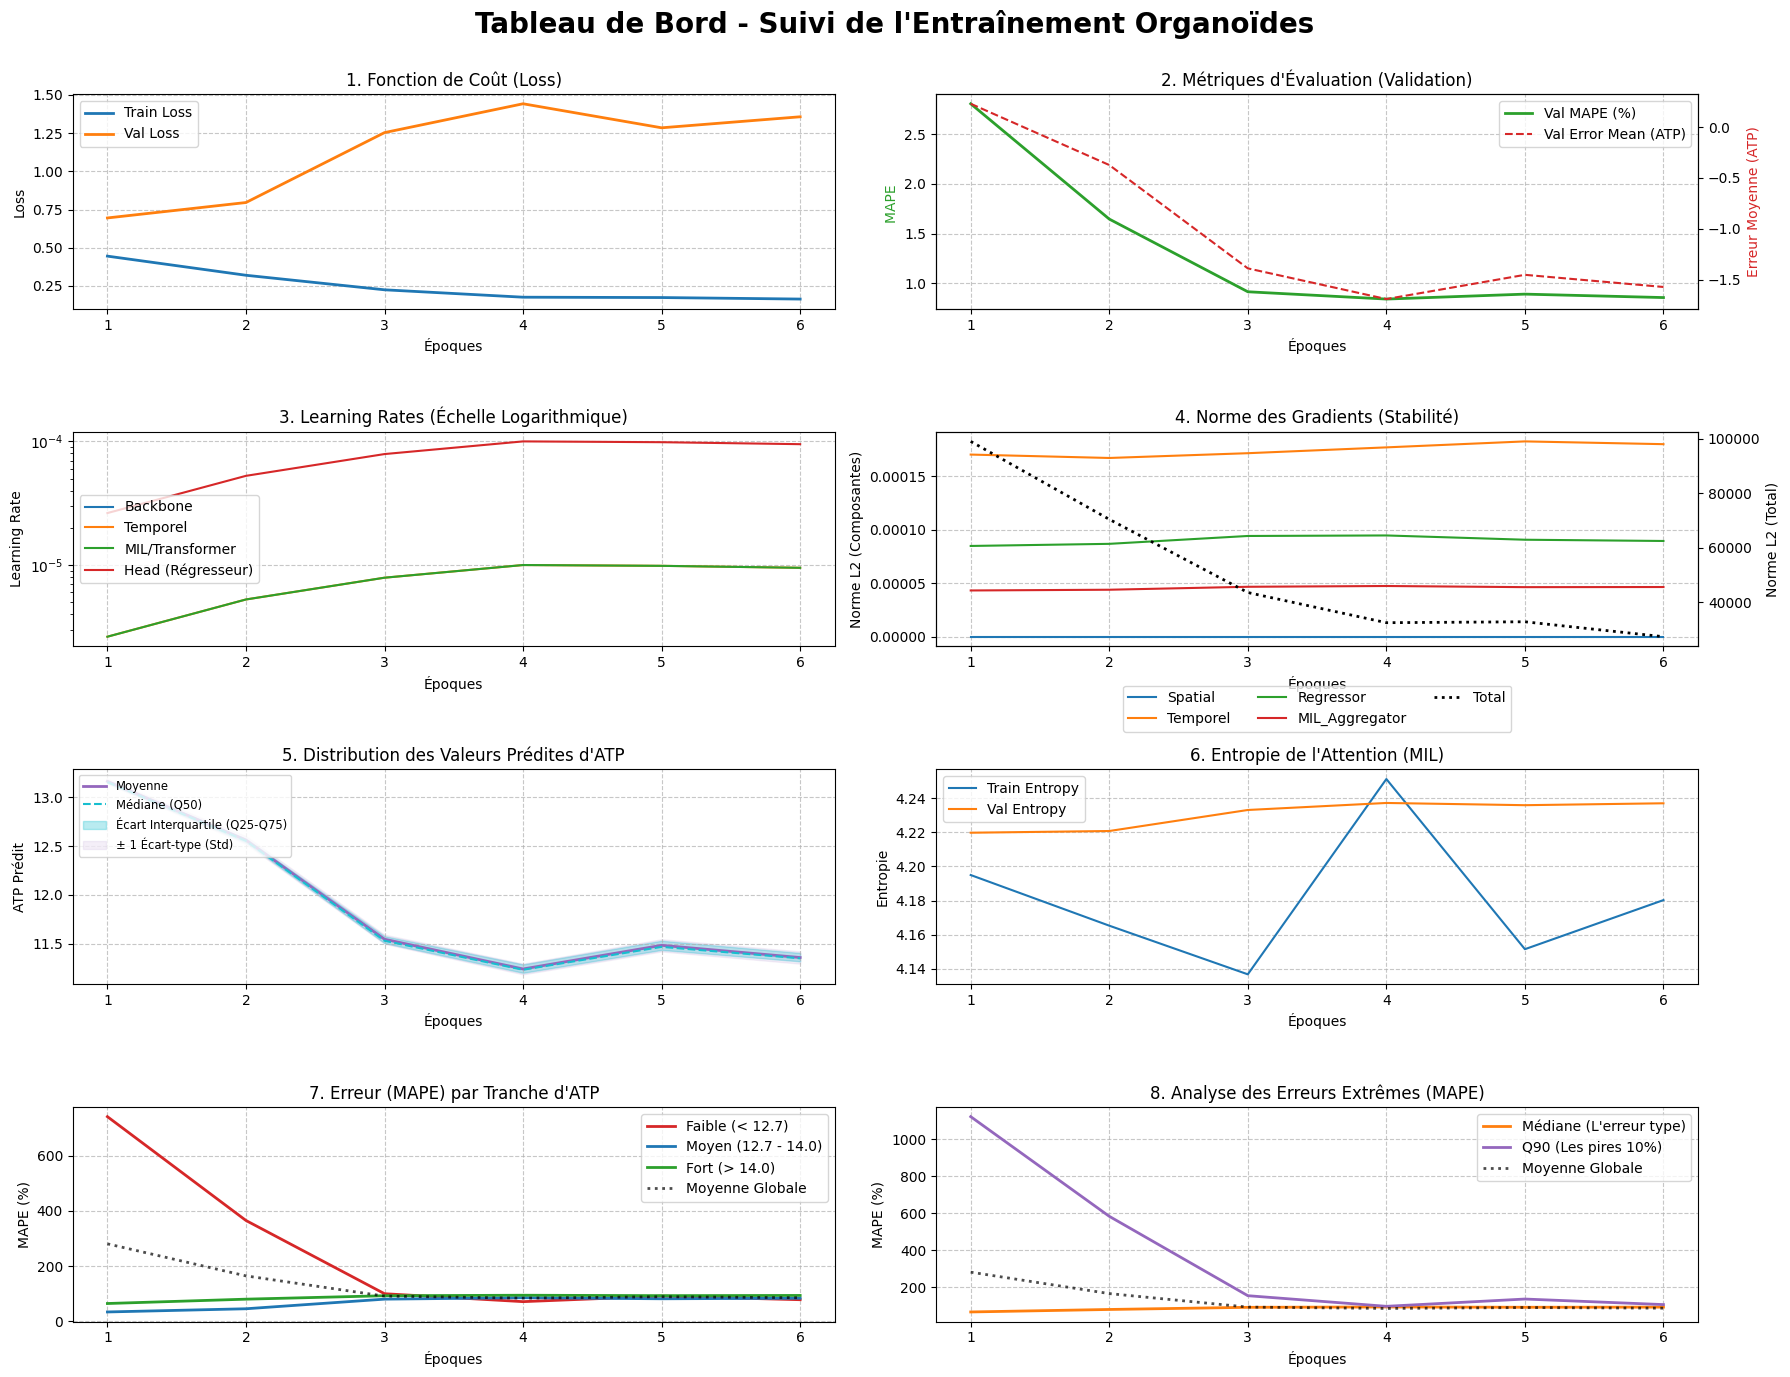

In [ ]:
def plot_training_dashboard(history):
    epochs = range(1, len(history['train_loss']) + 1)
    
    fig, axs = plt.subplots(4, 2, figsize=(18, 14))
    fig.suptitle("Tableau de Bord - Suivi de l'Entraînement Organoïdes", fontsize=20, fontweight='bold', y=0.98)

    axs[0, 0].plot(epochs, history['train_loss'], label='Train Loss', color='#1f77b4', linewidth=2)
    axs[0, 0].plot(epochs, history['val_loss'], label='Val Loss', color='#ff7f0e', linewidth=2)
    axs[0, 0].set_title('1. Fonction de Coût (Loss)')
    axs[0, 0].set_xlabel('Époques')
    axs[0, 0].set_ylabel('Loss')
    axs[0, 0].legend()
    axs[0, 0].grid(True, linestyle='--', alpha=0.7)

    ax2 = axs[0, 1].twinx()
    l1 = axs[0, 1].plot(epochs, history['val_mape'], label='Val MAPE (%)', color='#2ca02c', linewidth=2)
    l2 = ax2.plot(epochs, history['val_error_mean'], label='Val Error Mean (ATP)', color='#d62728', linestyle='--')
    
    axs[0, 1].set_title('2. Métriques d\'Évaluation (Validation)')
    axs[0, 1].set_xlabel('Époques')
    axs[0, 1].set_ylabel('MAPE ', color='#2ca02c')
    ax2.set_ylabel('Erreur Moyenne (ATP)', color='#d62728')
    
    lns = l1 + l2
    labs = [l.get_label() for l in lns]
    axs[0, 1].legend(lns, labs, loc='upper right')
    axs[0, 1].grid(True, linestyle='--', alpha=0.7)

    axs[1, 0].plot(epochs, history['lr_backbone'], label='Backbone')
    axs[1, 0].plot(epochs, history['lr_temp'], label='Temporel')
    axs[1, 0].plot(epochs, history['lr_mil'], label='MIL/Transformer')
    axs[1, 0].plot(epochs, history['lr_head'], label='Head (Régresseur)')
    
    axs[1, 0].set_yscale('log') 
    axs[1, 0].set_title('3. Learning Rates (Échelle Logarithmique)')
    axs[1, 0].set_xlabel('Époques')
    axs[1, 0].set_ylabel('Learning Rate')
    axs[1, 0].legend()
    axs[1, 0].grid(True, linestyle='--', alpha=0.7)

    l1 = axs[1, 1].plot(epochs, history['grad_norm_spatial'], label='Spatial')
    l2 = axs[1, 1].plot(epochs, history['grad_norm_temporal'], label='Temporel')
    l3 = axs[1, 1].plot(epochs, history['grad_norm_regressor'], label='Regressor')
    l4 = axs[1, 1].plot(epochs, history['grad_norm_mil_aggreg'], label='MIL_Aggregator')
    
    axs[1, 1].set_title('4. Norme des Gradients (Stabilité)')
    axs[1, 1].set_xlabel('Époques')
    axs[1, 1].set_ylabel('Norme L2 (Composantes)')
    axs[1, 1].grid(True, linestyle='--', alpha=0.7)

    ax4_twin = axs[1, 1].twinx()
    l5 = ax4_twin.plot(epochs, history['grad_norm_total'], label='Total', color='black', linewidth=2, linestyle=':')
    ax4_twin.set_ylabel('Norme L2 (Total)', color='black')

    lns = l1 + l2 + l3 + l4 + l5
    labs = [l.get_label() for l in lns]
    axs[1, 1].legend(lns, labs, loc='upper center', bbox_to_anchor=(0.5, -0.15), ncol=3) 

    axs[2, 0].plot(epochs, history['val_pred_mean'], label='Moyenne', color='#9467bd', linewidth=2)
    axs[2, 0].plot(epochs, history['val_pred_q50'], label='Médiane (Q50)', color='#17becf', linestyle='--')
    
    axs[2, 0].fill_between(epochs, history['val_pred_q25'], history['val_pred_q75'], 
                           color='#17becf', alpha=0.3, label='Écart Interquartile (Q25-Q75)')
    
    mean_arr = np.array(history['val_pred_mean'])
    std_arr = np.array(history['val_pred_std'])
    axs[2, 0].fill_between(epochs, mean_arr - std_arr, mean_arr + std_arr, 
                           color='#9467bd', alpha=0.1, label='± 1 Écart-type (Std)')
                           
    axs[2, 0].set_title('5. Distribution des Valeurs Prédites d\'ATP')
    axs[2, 0].set_xlabel('Époques')
    axs[2, 0].set_ylabel('ATP Prédit')
    axs[2, 0].legend(loc='upper left', fontsize='small')
    axs[2, 0].grid(True, linestyle='--', alpha=0.7)

    if len(history.get('attn_entropy', [])) > 0:
        axs[2, 1].plot(epochs, history['attn_entropy'], label='Train Entropy', color='#1f77b4')
    if len(history.get('val_attn_entropy', [])) > 0:
        axs[2, 1].plot(epochs, history['val_attn_entropy'], label='Val Entropy', color='#ff7f0e')
        
    axs[2, 1].set_title('6. Entropie de l\'Attention (MIL)')
    axs[2, 1].set_xlabel('Époques')
    axs[2, 1].set_ylabel('Entropie')
    axs[2, 1].legend()
    axs[2, 1].grid(True, linestyle='--', alpha=0.7)


    ax7 = axs[3, 0] 
    
    ax7.plot(epochs, history['val_mape_low'], label='Faible (< 12.7)', color='#d62728', linewidth=2)  
    ax7.plot(epochs, history['val_mape_mid'], label='Moyen (12.7 - 14.0)', color='#1f77b4', linewidth=2) 
    ax7.plot(epochs, history['val_mape_high'], label='Fort (> 14.0)', color='#2ca02c', linewidth=2)   
    
    ax7.plot(epochs, [h*100 for h in history['val_mape']], label='Moyenne Globale', color='black', linestyle=':', linewidth=2, alpha=0.7)
    
    ax7.set_title('7. Erreur (MAPE) par Tranche d\'ATP')
    ax7.set_xlabel('Époques')
    ax7.set_ylabel('MAPE (%)')
    
    ax7.legend(loc='upper right')
    ax7.grid(True, linestyle='--', alpha=0.7)


    ax8 = axs[3, 1] 
    
    ax8.plot(epochs, history['val_mape_median'], label='Médiane (L\'erreur type)', color='#ff7f0e', linewidth=2) 
    ax8.plot(epochs, history['val_mape_q90'], label='Q90 (Les pires 10%)', color='#9467bd', linewidth=2)       
    # ax8.plot(epochs, history['val_mape_max'], label='Max (La pire prédiction)', color='#8c564b', linewidth=2)   

    ax8.plot(epochs, [h*100 for h in history['val_mape']], label='Moyenne Globale', color='black', linestyle=':', linewidth=2, alpha=0.7)
    
    ax8.set_title('8. Analyse des Erreurs Extrêmes (MAPE)')
    ax8.set_xlabel('Époques')
    ax8.set_ylabel('MAPE (%)')
    
    ax8.legend(loc='upper right')
    ax8.grid(True, linestyle='--', alpha=0.7)

    

    plt.tight_layout()
    plt.subplots_adjust(top=0.92) 
    
    
    plt.show()


plot_training_dashboard(history)